In [ ]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 5.6 MB/s eta 0:00:00


In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import numpy as np


In [ ]:
# Load the datasets
df_mental_health = pd.read_csv('/content/mental_health.csv')  # Adjust the path accordingly
df_twitter = pd.read_csv('/content/Mental-Health-Twitter.csv', encoding='latin-1')


In [ ]:
# Check for missing values
print("Missing values in Mental Health Dataset:", df_mental_health.isnull().sum())
print("Missing values in Twitter Dataset:", df_twitter.isnull().sum())

Missing values in Mental Health Dataset: text     0
label    0
dtype: int64
Missing values in Twitter Dataset: Unnamed: 0      0
post_id         0
post_created    0
post_text       0
user_id         0
followers       0
friends         0
favourites      0
statuses        0
retweets        0
label           0
dtype: int64


In [ ]:
# Select relevant columns for both datasets
df_mental_health = df_mental_health[['text', 'label']]
df_twitter = df_twitter[['post_text', 'label']].rename(columns={'post_text': 'text'})

In [ ]:
# Combine both datasets into one dataframe
df_combined = pd.concat([df_mental_health, df_twitter], ignore_index=True)

# Drop missing values
df_combined.dropna(subset=['text', 'label'], inplace=True)

# Reset the index
df_combined.reset_index(drop=True, inplace=True)

In [ ]:
# Vectorization of Text Data Using TF-IDF
vectorizer = TfidfVectorizer(max_features=10000)
X_tfidf = vectorizer.fit_transform(df_combined['text'])

In [ ]:
# Dimensionality Reduction Using SVD
svd = TruncatedSVD(n_components=301)  # Experiment with this value
X_reduced = svd.fit_transform(X_tfidf)

In [ ]:
# Sentiment Analysis Using VADER
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    sentiment = analyzer.polarity_scores(text)
    return sentiment['compound']  # Return the compound score directly

df_combined['sentiment'] = df_combined['text'].apply(get_sentiment_score)

In [ ]:
# Feature Augmentation
X_augmented = pd.DataFrame(X_reduced)
X_augmented['sentiment'] = df_combined['sentiment']


In [ ]:
# Split the dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_augmented, df_combined['label'], test_size=0.2, random_state=42)

In [ ]:
# Train XGBoost Model
xgb_model = XGBClassifier(eval_metric='logloss', n_jobs=-1, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate Model Performance
print("XGBoost Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("XGBoost Accuracy Score:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost AUC Score:", roc_auc_score(y_test, y_pred_proba))

XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.85      4840
           1       0.85      0.82      0.84      4756

    accuracy                           0.84      9596
   macro avg       0.84      0.84      0.84      9596
weighted avg       0.84      0.84      0.84      9596

XGBoost Accuracy Score: 0.8412880366819508
XGBoost AUC Score: 0.9296863813608214


<Figure size 800x600 with 0 Axes>

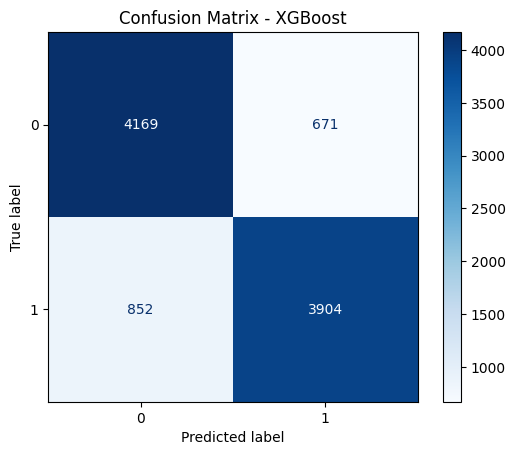

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - XGBoost")
plt.show()

In [ ]:
# Step 17: Save the Trained XGBoost Model and Vectorizer
joblib.dump(xgb_model, 'xgboost_model.pkl')
print("XGBoost model saved.")

joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("TF-IDF vectorizer saved.")

joblib.dump(svd, 'svd_model.pkl')
print("SVD model saved.")


XGBoost model saved.
TF-IDF vectorizer saved.
SVD model saved.


In [ ]:
# Function to make predictions on dynamic input
def predict_mental_health(input_text):
    # Step 1: Get sentiment score
    sentiment_score = get_sentiment_score(input_text)

    # Step 2: Vectorize the input text
    text_tfidf = vectorizer.transform([input_text])

    # Step 3: Reduce dimensionality using SVD
    text_reduced = svd.transform(text_tfidf)

    # Step 4: Prepare the input for prediction (adding sentiment as feature)
    input_features = pd.DataFrame(text_reduced)
    input_features['sentiment'] = sentiment_score

    # Step 5: Make prediction
    prediction = xgb_model.predict(input_features)
    prediction_proba = xgb_model.predict_proba(input_features)[:, 1]  # Get probabilities for the positive class (1)

    return prediction[0], prediction_proba[0]

# Dynamic input loop
while True:
    user_input = input("Enter a statement (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break

    label, probability = predict_mental_health(user_input)
    if label == 1:
        print(f"Mental Disorder Predicted with Probability: {probability:.2f}")
        print("Recommendation: Please consider reaching out to a mental health professional.")
    else:
        print("No Disorder Detected. Your mental health seems stable.")


# Dynamic input loop
while True:
    user_input = input("Enter a statement (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break

    label, probability = predict_mental_health(user_input)
    if label == 1:
        print(f"Mental Disorder Predicted with Probability: {probability:.2f}")
    else:
        print("No Disorder")


Enter a statement (or type 'exit' to quit): i feel sad #hate living
Mental Disorder Predicted with Probability: 0.96
Recommendation: Please consider reaching out to a mental health professional.
Enter a statement (or type 'exit' to quit): #fun filled day #smile
No Disorder Detected. Your mental health seems stable.
Enter a statement (or type 'exit' to quit): exit
Enter a statement (or type 'exit' to quit): exit


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Step 1: Load the multiclass dataset
multiclass_df = pd.read_csv('/content/Combined Data.csv')

# Step 2: Fill NaN values in the text features with an empty string
multiclass_df['statement'] = multiclass_df['statement'].fillna("")

# If target column has NaN values, fill them with the most frequent class (mode)
multiclass_df['status'] = multiclass_df['status'].fillna(multiclass_df['status'].mode()[0])

# Check unique classes
print("Unique classes in target variable:")
print(multiclass_df['status'].unique())

# Prepare the features and labels
X_multiclass = multiclass_df['statement']
y_multiclass = multiclass_df['status']

Unique classes in target variable:
['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']


In [ ]:
# Prepare the features and labels
X_multiclass = multiclass_df['statement']
y_multiclass = multiclass_df['status']

# Split the data
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
    X_multiclass, y_multiclass, test_size=0.2, random_state=42
)

In [ ]:
# Step 3: Encode the Target Labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_multi)
y_test_encoded = le.transform(y_test_multi)

In [ ]:
# Step 4: Vectorize Text Data Using TF-IDF
tfidf1_vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_tfidf = tfidf1_vectorizer.fit_transform(X_train_multi)
X_test_tfidf = tfidf1_vectorizer.transform(X_test_multi)


In [ ]:
# Step 5: Apply Dimensionality Reduction
n_components = 100  # Adjust based on experimentation
svd1 = TruncatedSVD(n_components=n_components)
X_train_reduced = svd.fit_transform(X_train_tfidf)
X_test_reduced = svd.transform(X_test_tfidf)

In [ ]:
# Step 6: Augment Data with VADER Sentiment Scores
analyzer = SentimentIntensityAnalyzer()

def add_sentiment_scores(text_data):
    sentiments = [analyzer.polarity_scores(text) for text in text_data]
    sentiment_df = pd.DataFrame(sentiments)
    return sentiment_df

In [ ]:
# Augment the training and testing datasets with VADER sentiment scores
train_sentiment = add_sentiment_scores(X_train_multi)
test_sentiment = add_sentiment_scores(X_test_multi)


In [ ]:
# Step 7: Combine Features (TF-IDF + Sentiment Scores)
X_train_combined = np.hstack([X_train_reduced, train_sentiment.values])
X_test_combined = np.hstack([X_test_reduced, test_sentiment.values])

In [ ]:
# Step 8: Train the XGBoost Model
xgb_model = XGBClassifier(eval_metric='mlogloss', n_jobs=-1)
xgb_model.fit(X_train_combined, y_train_encoded)

# Make predictions on the test set
y_pred = xgb_model.predict(X_test_combined)

In [ ]:
# Evaluate the model
accuracy = accuracy_score(y_test_encoded, y_pred)
print("Accuracy:", accuracy)

# Classification report
report = classification_report(y_test_encoded, y_pred, target_names=le.classes_)
print("Classification Report:\n", report)

Accuracy: 0.733622396078801
Classification Report:
                       precision    recall  f1-score   support

             Anxiety       0.76      0.69      0.73       779
             Bipolar       0.83      0.58      0.68       580
          Depression       0.66      0.71      0.68      3100
              Normal       0.85      0.93      0.89      3327
Personality disorder       0.65      0.51      0.57       248
              Stress       0.70      0.40      0.51       557
            Suicidal       0.63      0.64      0.63      2018

            accuracy                           0.73     10609
           macro avg       0.73      0.64      0.67     10609
        weighted avg       0.73      0.73      0.73     10609



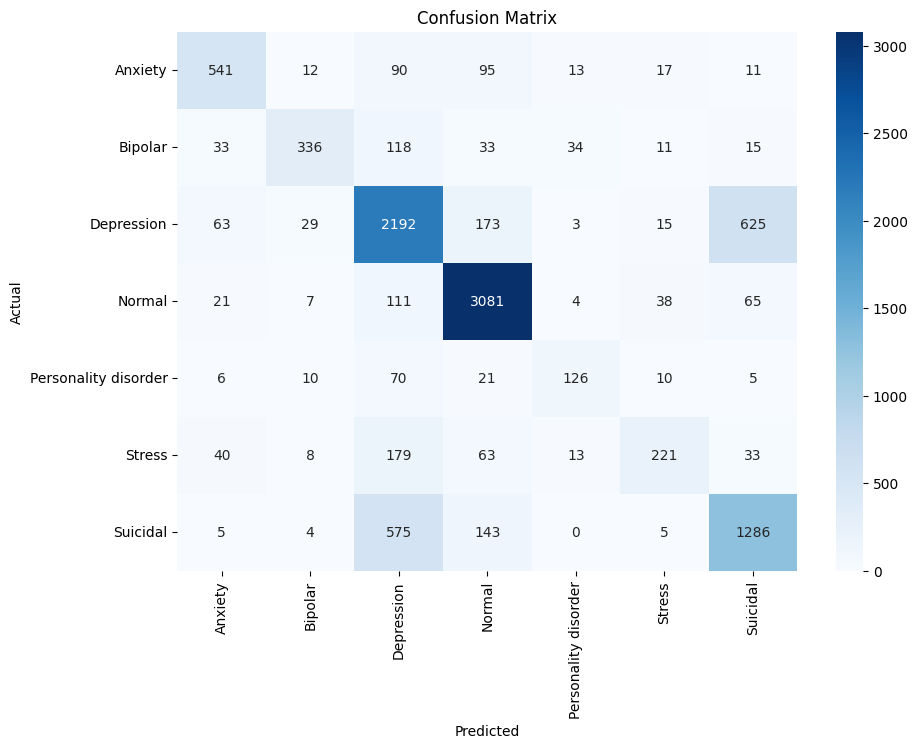

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# Binarize the output labels for AUC calculation
y_test_binarized = label_binarize(y_test_encoded, classes=np.unique(y_test_encoded))
n_classes = y_test_binarized.shape[1]

# Get the predicted probabilities
y_pred_proba = xgb_model.predict_proba(X_test_combined)

# Calculate AUC for each class
auc_scores = []
for i in range(n_classes):
    auc = roc_auc_score(y_test_binarized[:, i], y_pred_proba[:, i])
    auc_scores.append(auc)
    print(f"AUC for class '{le.classes_[i]}': {auc:.4f}")

# Calculate the average AUC score
average_auc = np.mean(auc_scores)
print(f"Average AUC score: {average_auc:.4f}")

AUC for class 'Anxiety': 0.9579
AUC for class 'Bipolar': 0.9638
AUC for class 'Depression': 0.8840
AUC for class 'Normal': 0.9786
AUC for class 'Personality disorder': 0.9454
AUC for class 'Stress': 0.9262
AUC for class 'Suicidal': 0.9093
Average AUC score: 0.9379


In [ ]:
# Save the models and components
joblib.dump(xgb_model, 'xgb_multiclass_model.pkl')
joblib.dump(tfidf1_vectorizer, 'tfidf1_vectorizer.pkl')
joblib.dump(svd, 'svd1_model.pkl')
joblib.dump(le, 'label1_encoder.pkl')
print("Models and components saved successfully.")

Models and components saved successfully.


In [ ]:
# Load the models and components for prediction
xgb_model = joblib.load('xgb_multiclass_model.pkl')
tfidf_vectorizer = joblib.load('tfidf1_vectorizer.pkl')
svd = joblib.load('svd1_model.pkl')
le = joblib.load('label1_encoder.pkl')

def preprocess_and_predict(new_text, tfidf_vectorizer, svd, xgb_model, le):
    # Preprocess the new text data
    new_text_df = pd.Series([new_text])  # Convert input to pandas Series

    # Fill NaN values (if necessary)
    new_text_df = new_text_df.fillna("")

    # Vectorize using the TF-IDF vectorizer
    new_text_tfidf = tfidf_vectorizer.transform(new_text_df)

    # Apply SVD to reduce dimensionality
    new_text_reduced = svd.transform(new_text_tfidf)

    # Add VADER sentiment scores
    sentiment_scores = add_sentiment_scores(new_text_df)

    # Combine TF-IDF and sentiment features
    new_text_combined = np.hstack([new_text_reduced, sentiment_scores.values])

    # Predict using the trained XGBoost model
    prediction = xgb_model.predict(new_text_combined)

    # Get predicted probabilities
    prediction_proba = xgb_model.predict_proba(new_text_combined)

    # Get the predicted class
    predicted_class = le.inverse_transform(prediction)[0]

    return predicted_class, prediction_proba

def get_dynamic_input(tfidf_vectorizer, svd, xgb_model, le):
    while True:
        new_text = input("Enter a statement (or type 'exit' to quit): ")
        if new_text.lower() == 'exit':
            print("Exiting the program.")
            break

        # Call the preprocess_and_predict function
        predicted_class, prediction_proba = preprocess_and_predict(new_text, tfidf_vectorizer, svd, xgb_model, le)

        print(f"Predicted Class: {predicted_class}")
        print(f"Prediction Probabilities: {prediction_proba}")

# Example usage
get_dynamic_input(tfidf_vectorizer, svd, xgb_model, le)


Enter a statement (or type 'exit' to quit): Every time I wake up, I'm definitely nervous and excited, until when are you going to try â„¢â€š Predicted Class: Anxiety
Predicted Class: Anxiety
Prediction Probabilities: [[8.2459837e-01 3.2271401e-03 5.3501282e-02 5.8952440e-02 7.1225280e-05
  4.8568338e-02 1.1081214e-02]]
Enter a statement (or type 'exit' to quit): Enter a statement (or type 'exit' to quit): I have been depression for 13 months now and recently I have emotional numbness. I need some advice and help.Have a lot to say and want to talk about but I do not know where to start and how and it will be really a huge post.But I really remember the day my depression started...it showed up suddenly while I was playing a game on my mom's phone. I was watching the character's special attack animation and she was beautiful made my heart pump a nice pump (Like that pump when you see ur crush) , and after that pump i felt my whole energy going down and my muscles down as well and was like

In [ ]:
import pandas as pd
import numpy as np
import joblib

# Load the binary model components
xgb_model = joblib.load('xgboost_model.pkl')  # Ensure this model is trained for binary classification
vectorizer = joblib.load('tfidf_vectorizer.pkl')  # Load the vectorizer for TF-IDF
svd = joblib.load('svd_model.pkl')  # Load the SVD model

# Load the models and components for multiclass prediction
xgb_multiclass_model = joblib.load('xgb_multiclass_model.pkl')
tfidf_vectorizer = joblib.load('tfidf1_vectorizer.pkl')
svd_multiclass = joblib.load('svd1_model.pkl')
le = joblib.load('label1_encoder.pkl')

# Function to get sentiment score
def get_sentiment_score(text):
    # Implement your sentiment analysis logic here
    # This is a placeholder; replace with actual sentiment score calculation
    return 0.5  # Example sentiment score

# Function to make predictions on dynamic input for binary classification
def predict_mental_health(input_text):
    # Step 1: Get sentiment score
    sentiment_score = get_sentiment_score(input_text)

    # Step 2: Vectorize the input text
    text_tfidf = vectorizer.transform([input_text])

    # Step 3: Reduce dimensionality using SVD
    text_reduced = svd.transform(text_tfidf)

    # Step 4: Prepare the input for prediction (adding sentiment as feature)
    input_features = pd.DataFrame(text_reduced)
    input_features['sentiment'] = sentiment_score

    # Step 5: Make prediction
    prediction = xgb_model.predict(input_features)
    prediction_proba = xgb_model.predict_proba(input_features)[:, 1]  # Get probabilities for the positive class (1)

    return prediction[0], prediction_proba[0]

# Function to preprocess and predict for multiclass classification
def preprocess_and_predict(new_text):
    # Preprocess the new text data
    new_text_df = pd.Series([new_text])  # Convert input to pandas Series
    new_text_df = new_text_df.fillna("")  # Fill NaN values (if necessary)

    # Vectorize using the TF-IDF vectorizer
    new_text_tfidf = tfidf_vectorizer.transform(new_text_df)

    # Apply SVD to reduce dimensionality
    new_text_reduced = svd_multiclass.transform(new_text_tfidf)

    # Add VADER sentiment scores
    sentiment_scores = add_sentiment_scores(new_text_df)

    # Combine TF-IDF and sentiment features
    new_text_combined = np.hstack([new_text_reduced, sentiment_scores.values])

    # Predict using the trained XGBoost model
    prediction = xgb_multiclass_model.predict(new_text_combined)

    # Get predicted probabilities
    prediction_proba = xgb_multiclass_model.predict_proba(new_text_combined)

    # Get the predicted class
    predicted_class = le.inverse_transform(prediction)[0]

    return predicted_class, prediction_proba

# Dynamic input loop for binary classification
while True:
    user_input = input("Enter a statement (or type 'exit' to quit): ")
    if user_input.lower() == 'exit':
        break

    label, probability = predict_mental_health(user_input)
    if label == 1:
        print(f"Mental Disorder Predicted with Probability: {probability:.2f}")
        print("Proceeding to multiclass classification...")

        # Perform multiclass classification
        predicted_class, prediction_proba = preprocess_and_predict(user_input)
        print(f"Predicted Class: {predicted_class}")
        print(f"Prediction Probabilities: {prediction_proba}")
        print("Recommendation: Please consider reaching out to a mental health professional.")
    else:
        print("No Disorder Detected. Your mental health seems stable.")


Enter a statement (or type 'exit' to quit): happy moments #memories filled with fun
Mental Disorder Predicted with Probability: 0.53
Proceeding to multiclass classification...
Predicted Class: Normal
Prediction Probabilities: [[4.0394542e-04 5.3076941e-04 9.1715036e-03 9.8495865e-01 2.6756231e-04
  3.6659537e-04 4.3009426e-03]]
Recommendation: Please consider reaching out to a mental health professional.
Enter a statement (or type 'exit' to quit): Married Ex-Coworker Stress So, there's a situation that occurred and it's tearing me apart from the inside. I'm absolutely terrible at showing emotions and "making a move." Hence my "terminal aloneness." *I wish it was terminal...*  Last year, during the summer I temporarily got to experience what it was like to be "wanted." A coworker and I became friends, and she seemed to express interest in me. Time and time I'd go hang out with her, only to go home banging my head in frustration and wondering wtf was going on.   Here's my only other post